<a href="https://colab.research.google.com/github/nawroz-m/ML_learning/blob/main/food_vision.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Food Vision

## Check the GPU
Google Colab offer free GPU, however not all of them are compatible with `mixed precision training`

[Google Colab offers](https://developer.nvidia.com/cuda-gpus):

* K80(not compatible)
* P100(not compatible)
* Tesla T4(compatible)

In [1]:
!nvidia-smi -L

GPU 0: Tesla T4 (UUID: GPU-bd73eacb-d122-5241-f32d-73279c64f02a)


## Use TensorFlow Dataset to download data

In [2]:
import tensorflow_datasets as tfds
import tensorflow as tf
import matplotlib.pyplot as plt


In [3]:
# list the available dataset
dataset_list = tfds.list_builders()
print('food101' in dataset_list) # it's a very long list so just check if your dataset is exist

True


In [ ]:
# load the dataset
(train_data, test_data), ds_info = tfds.load(name='food101',
                                             split=['train', 'validation'],
                                             as_supervised= True, # data get return in key value per(Tuple)
                                             shuffle_files=True,
                                             with_info=True)

# Exploring the food1001 data from TensorFlow Datasets
To become one with our data we want to find:
* Class names
* The shape of our input data (image tensore)
* The data type of our input data
* What the labels look like(e.g. are they one-hot encoded or are they label encoded)
* Do the label mutch up with the class names?

In [5]:
# Feature of food101 from TFDS
ds_info.features

FeaturesDict({
    'image': Image(shape=(None, None, 3), dtype=uint8),
    'label': ClassLabel(shape=(), dtype=int64, num_classes=101),
})

In [6]:
# Get the class names
class_names = ds_info.features['label'].names
class_names[:10]

['apple_pie',
 'baby_back_ribs',
 'baklava',
 'beef_carpaccio',
 'beef_tartare',
 'beet_salad',
 'beignets',
 'bibimbap',
 'bread_pudding',
 'breakfast_burrito']

In [7]:
train_data

<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [8]:
# Take one sample of the train data
train_one_sample = train_data.take(1) # samples are in the form of (image_tensor, label)
# What does one sample of our training data looks like
train_one_sample

<_TakeDataset element_spec=(TensorSpec(shape=(None, None, 3), dtype=tf.uint8, name=None), TensorSpec(shape=(), dtype=tf.int64, name=None))>

In [9]:
# Output info about our training data
for image, label in train_one_sample:
  print(f"""
        Image shape: {image.shape}
        Image datatype: {image.dtype}
        Target classe from food100(tensor form): {label}
        Class name(str form):  {class_names[label.numpy()]}
  """)


        Image shape: (512, 512, 3)
        Image datatype: <dtype: 'uint8'>
        Target classe from food100(tensor form): 90
        Class name(str form):  spaghetti_bolognese
  


In [10]:
# What does our image data from TFDS looks like?
image

<tf.Tensor: shape=(512, 512, 3), dtype=uint8, numpy=
array([[[ 12,  13,   7],
        [ 12,  13,   7],
        [ 13,  14,   8],
        ...,
        [ 21,  11,   0],
        [ 21,  11,   0],
        [ 21,  11,   0]],

       [[ 12,  13,   7],
        [ 11,  12,   6],
        [ 11,  12,   6],
        ...,
        [ 21,  11,   0],
        [ 21,  11,   0],
        [ 21,  11,   0]],

       [[  7,   8,   2],
        [  7,   8,   2],
        [  7,   8,   2],
        ...,
        [ 22,  12,   2],
        [ 21,  11,   1],
        [ 20,  10,   0]],

       ...,

       [[188, 191, 184],
        [188, 191, 184],
        [188, 191, 184],
        ...,
        [243, 248, 244],
        [243, 248, 244],
        [242, 247, 243]],

       [[187, 190, 183],
        [189, 192, 185],
        [190, 193, 186],
        ...,
        [241, 245, 244],
        [241, 245, 244],
        [241, 245, 244]],

       [[186, 189, 182],
        [189, 192, 185],
        [191, 194, 187],
        ...,
        [238, 242, 24

In [11]:
# What are the min and max values of our image tensor?
tf.reduce_min(image), tf.reduce_max(image)

(<tf.Tensor: shape=(), dtype=uint8, numpy=0>,
 <tf.Tensor: shape=(), dtype=uint8, numpy=255>)

## Plot an image form Tensorflow Dataset

(np.float64(-0.5), np.float64(511.5), np.float64(511.5), np.float64(-0.5))

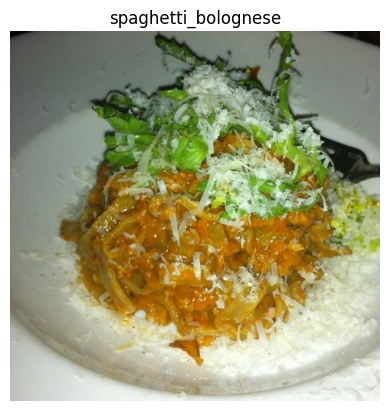

In [12]:
# Plot an image
plt.imshow(image)
plt.title(class_names[label.numpy()])
plt.axis(False)

## Preprocess the data
Neural Network work best when the data is in certain way. e.g (Normalized, batched, and etc). However not all data including `Tensorflow Dataset` comes like this.

What we know about our data:
* It's in `unit8`
* Comprised of all diffirent size tensors (diffirent size of images)
* It's not scaled, the pixel values are between 0 and 255
What a model like:
* Data in `float32` dtype(or for mixed percision `float16` and `float32`)
* For `batches`, Tensorflow likes all of the tensors within a batch to be of the same size
* `Scaled`(Values between 0 and 1) also called normalization tensors perform better

Since we're going to use `EfficientNetBX` pretrained model from keras application we don't need to rescale our data(these architecture have rescalling build-in)

And Since we are not using `image_dataset_from_directory` we need the following steps:
* Make sure all the training and testing dataset has the same `shape`
* Covert the dtype of image tensors from `uint8` to `float32`
* We need to `normalize` the dataset
* Make sure our data is `Shuffled` during the training process
* Create `batches`


In [13]:
# Make a function for prepocessing the image
def preprocess_img(image, label, img_shape=224):
  """
  Convert image data type from `uint8` -> `float32` and reshape image to [img_shape, img_shape, color_channels]
  """
  image = tf.image.resize(image, size=[img_shape, img_shape]) # Reshape the target image
  # image = image/255. # rescale the image is not require in efficiennetbx from tensorflow dataset
  return tf.cast(image, tf.float32), label # Return (float32_image, label) tuple


In [14]:
# Prprocess a single sample image and check the output
take_one_image =train_data.take(1)
image, label = next(iter(take_one_image))
preprocess_img_data = preprocess_img(image, label)
print(f'Image data befor preprocessing: \n  {image[2]} ....., \n Shape: {image.shape}\n Datatype: {image.dtype}')
print(f'Image data after preprocessing: \n  {preprocess_img_data[:2]} ....., \n Shape: {preprocess_img_data[0].shape}\n Datatype: {preprocess_img_data[0].dtype}')



Image data befor preprocessing: 
  [[ 40  43  22]
 [ 45  48  27]
 [ 50  55  33]
 ...
 [ 90 119  71]
 [ 87 116  68]
 [ 84 113  65]] ....., 
 Shape: (512, 512, 3)
 Datatype: <dtype: 'uint8'>
Image data after preprocessing: 
  (<tf.Tensor: shape=(224, 224, 3), dtype=float32, numpy=
array([[[ 46.2551   ,  49.2551   ,  28.255102 ],
        [ 49.954082 ,  54.954082 ,  32.954082 ],
        [ 42.494896 ,  50.494896 ,  27.494898 ],
        ...,
        [ 97.50995  , 129.86195  ,  81.4385   ],
        [ 94.02041  , 122.21427  ,  77.33163  ],
        [ 86.42833  , 112.71404  ,  68.78547  ]],

       [[ 45.336735 ,  48.336735 ,  27.336735 ],
        [ 53.714287 ,  58.714287 ,  36.714287 ],
        [ 40.44388  ,  48.44388  ,  25.443878 ],
        ...,
        [ 92.948906 , 128.3213   ,  74.52029  ],
        [ 85.48981  , 117.27552  ,  67.41838  ],
        [ 90.70417  , 122.48989  ,  72.632744 ]],

       [[ 48.795918 ,  53.795918 ,  30.79592  ],
        [ 59.428574 ,  64.42857  ,  41.428574 ],
    

# Batch & prepare datasets
With tf.data API the input data pipeline runs very fast


In [26]:
# Map preprocessing function to train (and parallelize)
train_data = train_data.map(map_func=preprocess_img, # apply the preprocess func while looping through training data
                            num_parallel_calls=tf.data.AUTOTUNE) # As this func run TF will automatically tune the number of processor it use or utilize as many processor you found

# Shuffle train_data and trun it into batches and prefetch it(load it faster)
train_data = train_data.shuffle(buffer_size=1000 # How many element to shuffle at a single time, idealy it's every element in the training dataset(len(train_data))
                                ).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

# Map preprocessing function to test data
test_data = test_data.map(map_func=preprocess_img, num_parallel_calls=tf.data.AUTOTUNE)
test_data = test_data.shuffle(buffer_size=1000).batch(batch_size=32).prefetch(buffer_size=tf.data.AUTOTUNE)

> "Hey, Tensorflow, map this preporcessing function(`preporcess_img`) across our training dataset, then shuffle a number of elements and then batch them together and finally make sure you prepare new batches(`prefetch`) while the model is looking through(finding patterns) the correct batch"

In [32]:
train_data, test_data


(<_PrefetchDataset element_spec=(TensorSpec(shape=(None, None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None, None), dtype=tf.int64, name=None))>,
 <_PrefetchDataset element_spec=(TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name=None), TensorSpec(shape=(None,), dtype=tf.int64, name=None))>)